In [1]:
from shiny import ui, render, reactive, App
import pandas as pd
from ploting_profiles import violin_plot_grouped_by_sex_and_age_group
import matplotlib.pyplot as plt
from shinywidgets import output_widget
from io import BytesIO
import base64
import pickle
import shap
# UI for the Sample tab


# Load the datasets
# data/shap_values_ridge.pkl' has the shap_values
shap_values_ridge = pickle.load(open("data/shap_values_ridge.pkl", "rb"))
shap_values_catboost = pickle.load(open("data/shap_values_catboost.pkl", "rb"))

In [3]:
sample_data = pd.read_csv("data/validation_sample_data.csv")


In [32]:
shap_values_catboost

.values =
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

.base_values =
array([50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.21705627, 50.21705627, 50.21705627, 50.21705627, 50.21705627,
       50.217

In [4]:
shap_values = shap_values_catboost

In [24]:
import matplotlib.pyplot as plt

for sampe_number in range(108):
    patient = sample_data.loc[sampe_number]
    fig = shap.plots.waterfall(shap_values[sampe_number], show=False)

    index= sampe_number - 1
    title = f"Age: {patient['Age']} \n Status: {patient['Status']}"
    plt.title(title)
    plt.savefig(f"shap_waterfall_Catboost_sample_{index}.svg",bbox_inches="tight")
    plt.close()


In [82]:
genes_top_50 = {}
for sample_number in range(108):#[3,4,17,24,28,30,33,41,49]:
    patient = sample_data.loc[sample_number]
    gene_names = shap_values.feature_names
    values = shap_values[sample_number]
    gene_value_pairs = list(zip(gene_names, values.values))
    gene_value_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    genes_top_50[sample_number] = gene_value_pairs[:50]
    

In [85]:
# get genes that appear in top 50 for all samples
from collections import Counter
all_top_genes = []
for gene_list in genes_top_50.values():
    all_top_genes.extend([gene for gene, value in gene_list])
gene_counts = Counter(all_top_genes)
common_top_genes = set([gene for gene, count in gene_counts.items() if count == len(genes_top_50)])
len(common_top_genes)

26

In [86]:
common_top_genes

{'ABCD4',
 'ACIN1',
 'CFD',
 'DAPK2',
 'EIF5A',
 'ENSG00000262855.1',
 'ENSG00000285043.1',
 'FBXO31',
 'FEZ2',
 'H3-3B',
 'HMGB2',
 'HNRNPM',
 'ILF3',
 'KLC1',
 'MICAL3',
 'MORF4L2',
 'MTFR1',
 'MYH8',
 'SDHAP1',
 'SEPTIN2',
 'SLC16A3',
 'STUM',
 'UBE2H',
 'UBFD1',
 'WDR74',
 'ZNF710'}

In [87]:
# get genes that ONLY appear in top 50 for one sample
unique_top_genes = set([gene for gene, count in gene_counts.items() if count == 1])
len(unique_top_genes)

12

In [88]:
unique_top_genes

{'ACSL1',
 'ALG9',
 'CPNE1',
 'ENSG00000270835.2',
 'KDM3B',
 'KIF2A',
 'LAMC1',
 'MTIF2',
 'PKIA',
 'PPP2R5A',
 'SAR1A',
 'TRAFD1'}

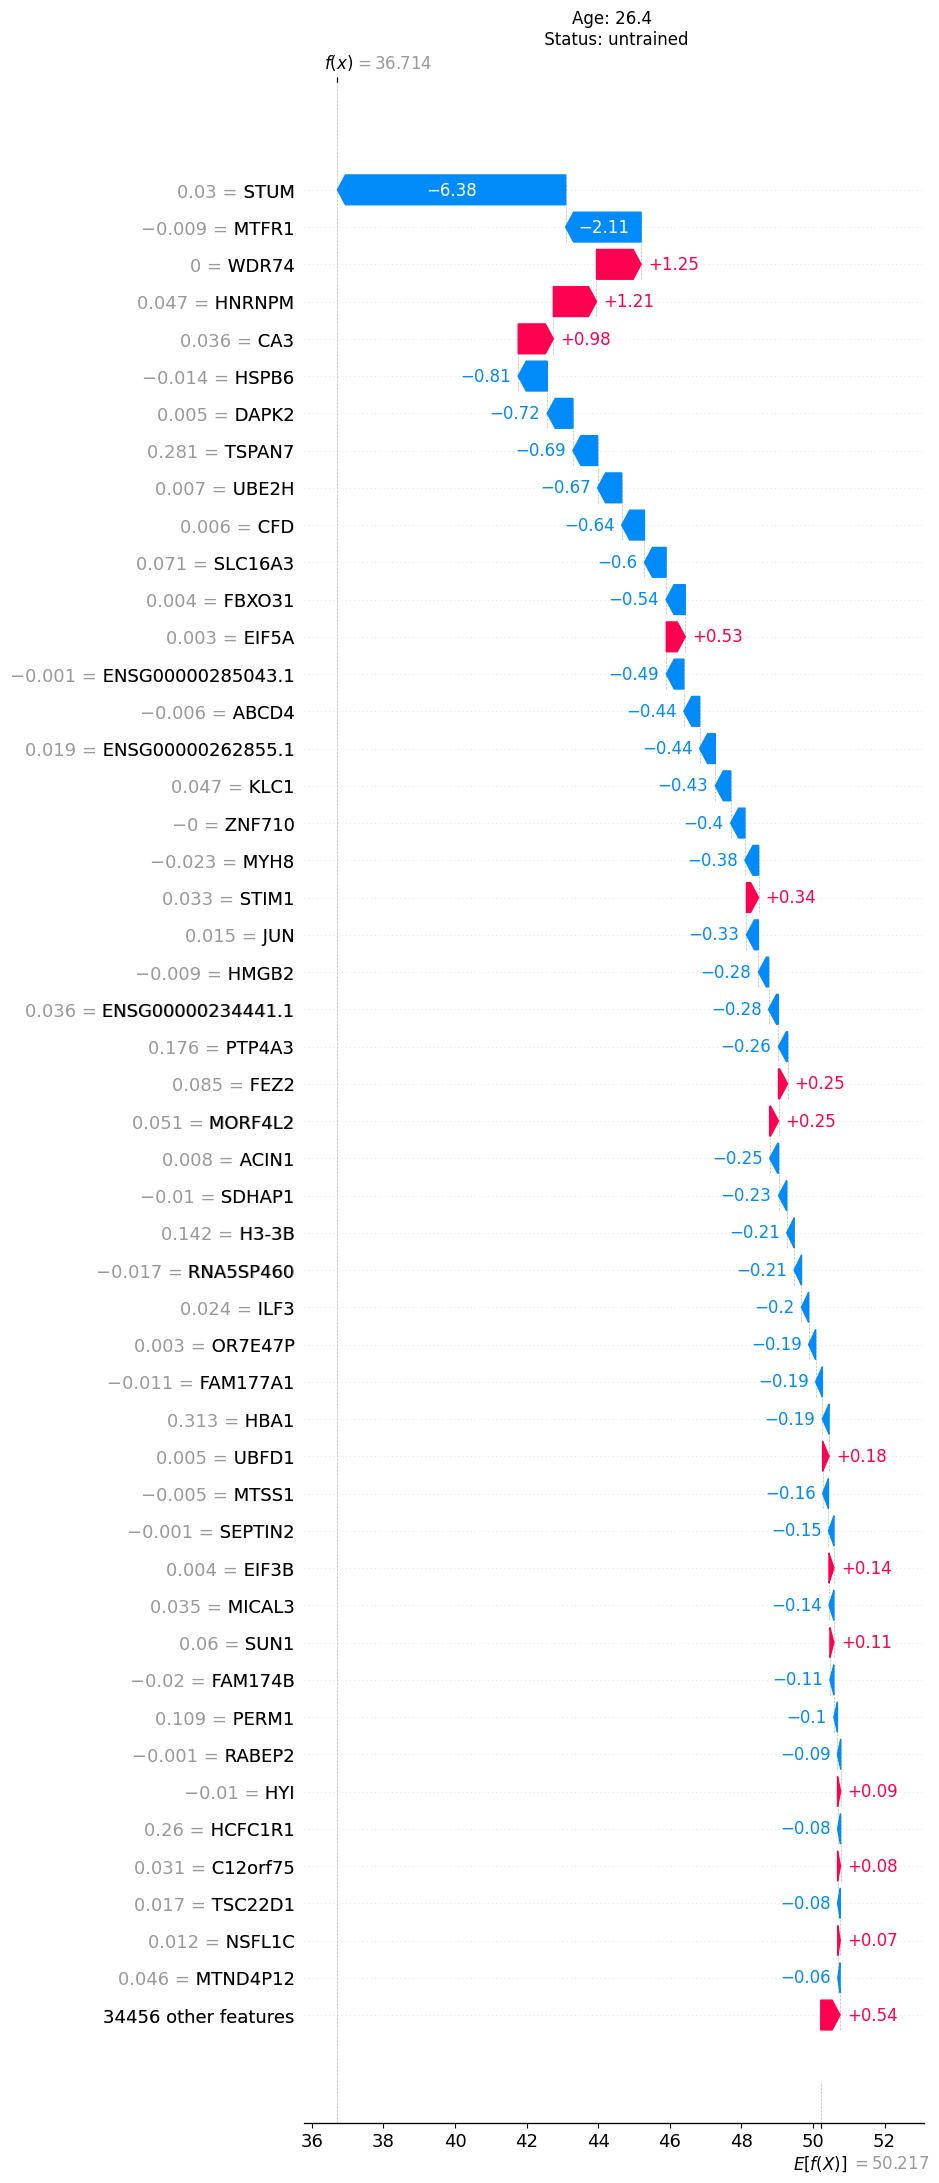

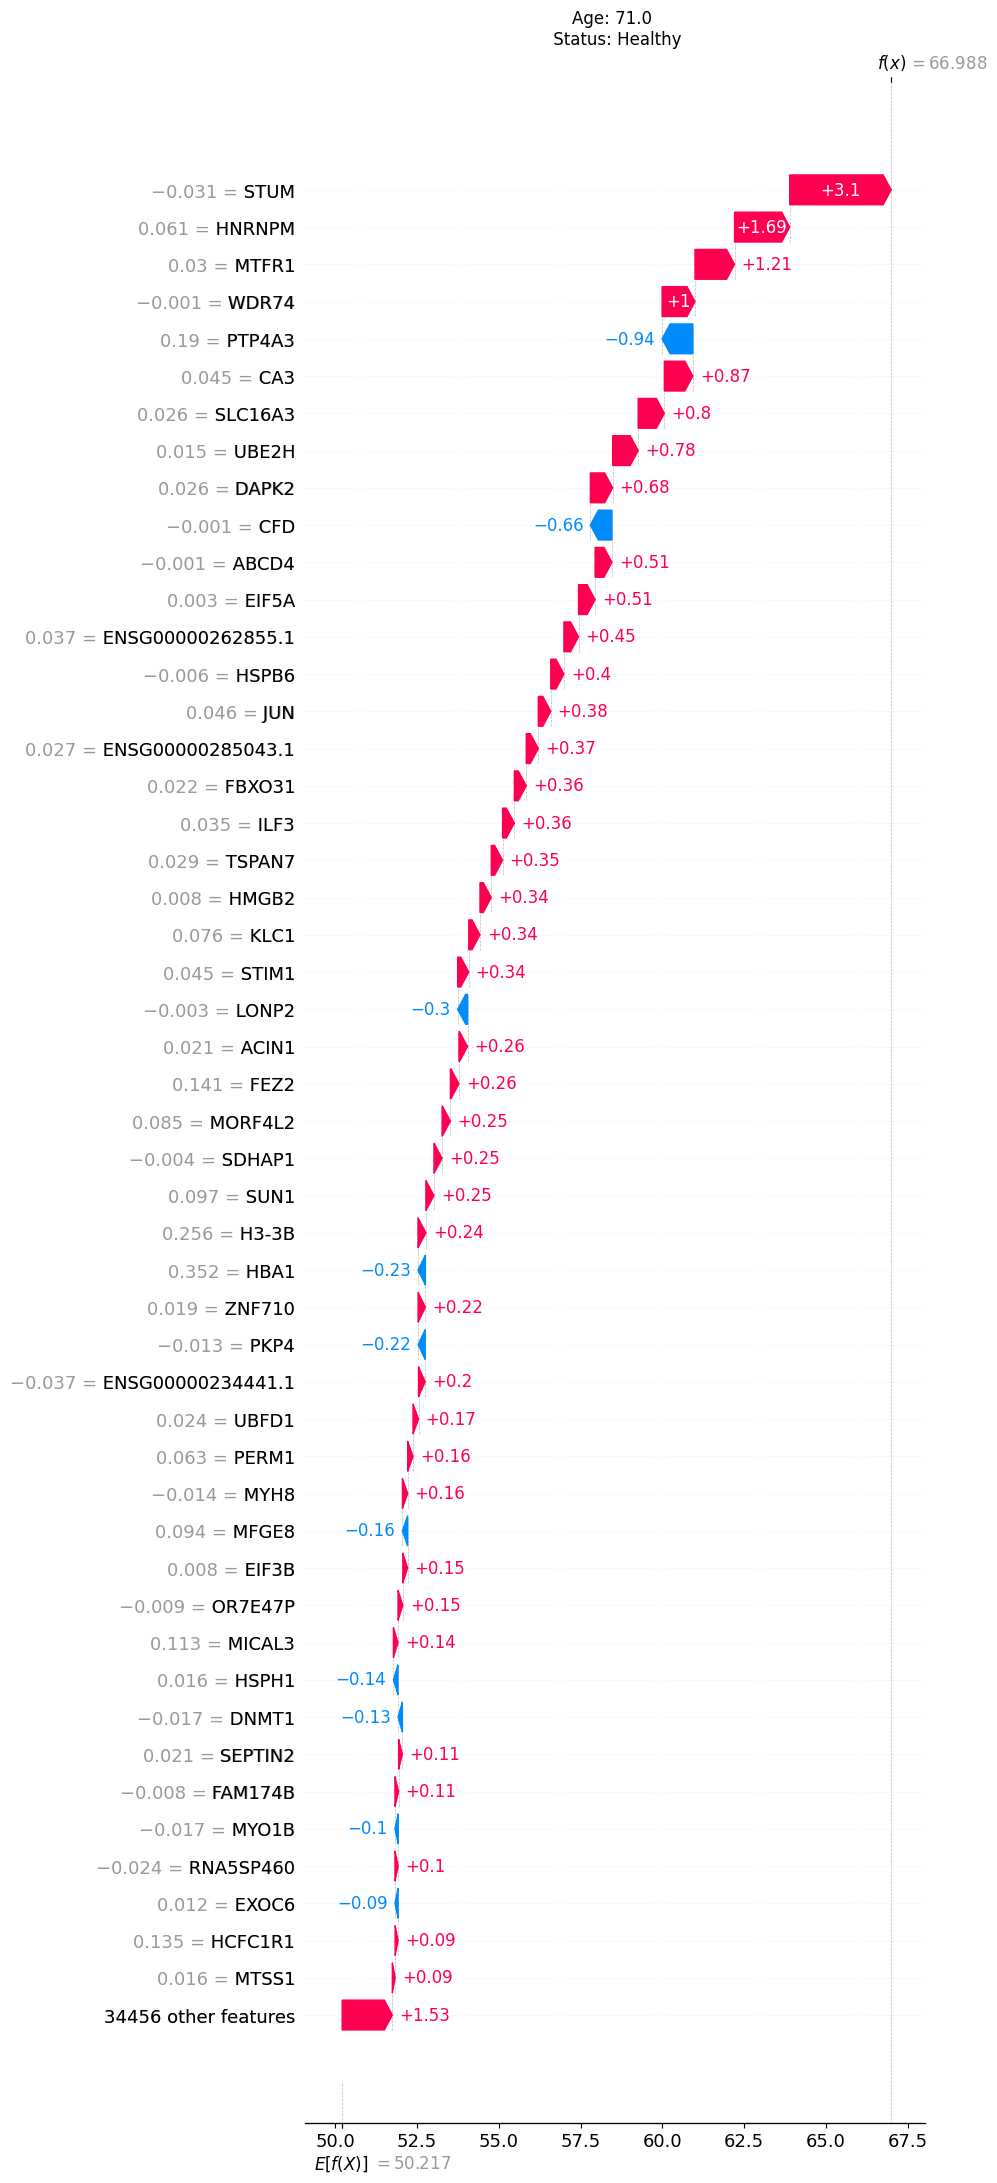

KeyboardInterrupt: 

In [80]:
for sampe_number in [3,4,17,24,28,30,33,41,49]:
    patient = sample_data.loc[sampe_number]
    fig = shap.plots.waterfall(shap_values[sampe_number], show=False, max_display=50)

    index= sampe_number - 1
    title = f"Age: {patient['Age']} \n Status: {patient['Status']}"
    plt.title(title)
    plt.savefig(f"shap_waterfall_Catboost_sample_{index}_50.svg",bbox_inches="tight")
    plt.show()
    plt.close()

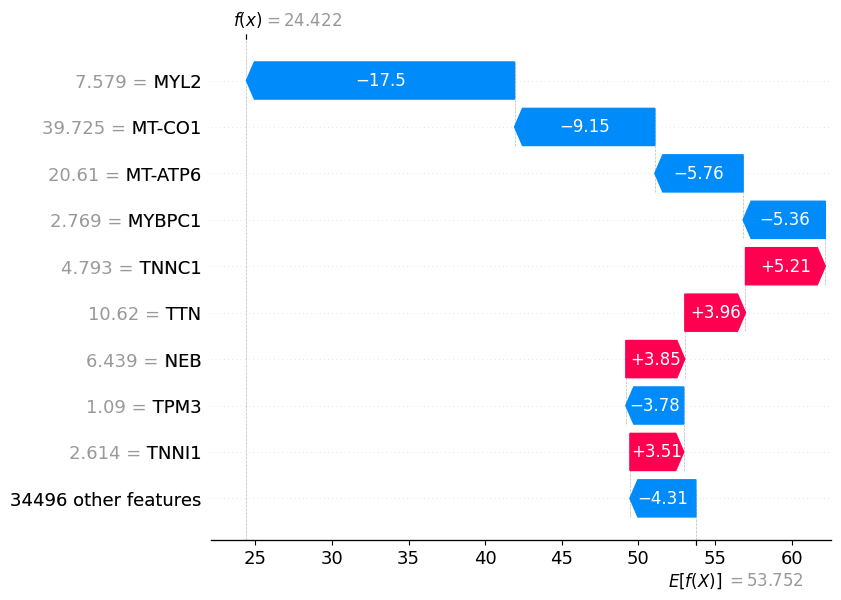

In [12]:
shap.plots.waterfall(shap_values_ridge[sample_number])

In [31]:

for sampe_number in [30,47]:
    patient = sample_data.loc[sampe_number]
    fig = shap.plots.waterfall(shap_values[sampe_number], show=False, max_display=20)

    index= sampe_number - 1
    title = f"Age: {patient['Age']} \n Status: {patient['Status']}"
    plt.title(title)
    plt.savefig(f"shap_waterfall_Catboost_sample_{index}_20_genes.svg",bbox_inches="tight")
    plt.close()

In [14]:
sample_data.loc[sample_number]['Status']

'Healthy'

In [11]:
sample_data[sample_data['Status']=='Healthy'].head(20)

,Status,Experiment,Age,Sample,Sex,RidgeP,CatboostP
0,Healthy,GSE157585,24.0,SRR12604218,NaN,29.056820,23.221191
1,Healthy,GSE167186,18.0,SRR13759023,NaN,24.422029,26.198732
2,Healthy,GSE167186,23.0,SRR13759025,NaN,20.977246,24.289711
4,Healthy,GSE157585,71.0,SRR12604184,NaN,77.621266,68.304524
6,Healthy,GSE157585,71.0,SRR12604120,NaN,61.745417,69.392695
8,Healthy,GSE164471,31.0,SRR13388734,male,23.186481,30.595556
10,Healthy,GSE152558,46.0,SRR12021926,male,61.685428,48.231464
11,Healthy,GSE167186,84.0,SRR13759029,male,70.963710,68.072074
13,Healthy,GSE129643,45.0,SRR8882178,male,45.417903,45.460597
15,Healthy,GSE157585,71.0,SRR12604111,NaN,75.617666,68.980394
